# CNN Classifier: Car vs Motorcycle

This notebook builds a simple **Convolutional Neural Network (CNN)** using **TensorFlow/Keras** to classify images as either a **Car** or a **Motorcycle**.

We will go step by step:
1. Load the dataset
2. Resize images to 128x128
3. Normalize pixel values
4. Split into train/test sets
5. Build the CNN
6. Compile the model
7. Train for at least 10 epochs
8. Evaluate on test data
9. Show predictions on sample images
10. Plot accuracy/loss curves


```
dataset/
    car/
        img1.jpg
        img2.jpg
        ...
    motorcycle/
        img1.jpg
        img2.jpg
        ...
```

Insted of car vs motorcycle we can use the 
1. cat vs dog
2. apple vs orange
3. rock vs paper
4. paper vs rock
5. Horse vs human

# THE CODE WILL EXACTLY REMAIN SAME FOR EACH OF THE ABOVE DATASET MENTIONED, JUST THE DATASET ITSELF WILL CHANGE 


## Step 0: Import Libraries

We only use **TensorFlow/Keras**, along with `matplotlib` for plotting and `numpy` for basic array handling.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Load the Car vs Motorcycle Dataset

We use Keras' built-in helper `image_dataset_from_directory`, which:
- Reads images directly from folders (one folder per class)
- Automatically labels images based on folder name
- Handles batching for us

Update `DATASET_DIR` below to point to your dataset folder (it should contain two subfolders: `car` and `motorcycle`).

In [2]:
# Path to your dataset folder (change this to your actual path)
DATASET_DIR = "D:\dataset"   # dataset/car/*.jpg , dataset/motorcycle/*.jpg
#DATASET_DIR = "Z:\dataset" # For the college exam you need to write Z drive 

IMG_SIZE = (128, 128)   # Step 2: images will be resized to 128x128
BATCH_SIZE = 32

# Load training data (80% of images)
train_ds = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,   # <-- resizing happens automatically here (Step 2)
    batch_size=BATCH_SIZE,
    label_mode="binary"    # since we have 2 classes: car vs motorcycle
)

# Load validation/testing data (remaining 20% of images) -> Step 4: train/test split
test_ds = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_ds.class_names
print("Classes found:", class_names)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Classes found: ['rock', 'scissors']


## Step 2: Resize Images to 128x128

This is already handled above by `image_size=(128, 128)` in `image_dataset_from_directory`. Every image loaded from disk is automatically resized to 128×128 pixels, so no extra code is needed here.

## Step 3: Normalize Pixel Values (0 to 1)

Images are loaded with pixel values in the range **0–255**. We normalize them to **0–1** by dividing by 255 (Min-Max Normalization). This helps the CNN train faster and more stably.

In [3]:
def normalize(x, y):
    x = x / 255.0
    return x, y

train_ds = train_ds.map(normalize)
test_ds = test_ds.map(normalize)

print("Pixel values are now normalized between 0 and 1.")

Pixel values are now normalized between 0 and 1.


## Step 4: Train/Test Split

The dataset was already split into **training (80%)** and **testing (20%)** sets in Step 1 using `validation_split=0.2`. `train_ds` is our training set, and `test_ds` is our testing set.

## Step 5: Build the CNN Model

Our CNN architecture (as required):
- **Convolutional layers** → extract visual features (edges, shapes, textures)
- **ReLU activation** → adds non-linearity
- **MaxPooling layers** → reduce image size, keep important features
- **Flatten layer** → converts 2D feature maps into a 1D vector
- **Dense layer** → learns to combine features for classification
- **Sigmoid output layer** → outputs a probability between 0 and 1 (0 = one class, 1 = other class), suitable for binary classification

In [4]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten + Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # Sigmoid output for binary classification
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

## Step 6: Compile the Model

- **Optimizer**: `adam` — a widely used, efficient optimizer for CNNs
- **Loss function**: `binary_crossentropy` — the standard loss for binary (2-class) classification with a sigmoid output
- **Metric**: `accuracy` — to track classification performance

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Step 7: Train the CNN

We train for **at least 10 epochs**, using `train_ds` for training and `test_ds` for validation, so we can track performance after every epoch.

In [6]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/10
25/25 [==============================] - 22s 709ms/step - loss: 0.7016 - accuracy: 0.5213 - val_loss: 0.6706 - val_accuracy: 0.7450
Epoch 2/10
25/25 [==============================] - 12s 457ms/step - loss: 0.5587 - accuracy: 0.7738 - val_loss: 0.3958 - val_accuracy: 0.8250
Epoch 3/10
25/25 [==============================] - 13s 487ms/step - loss: 0.3560 - accuracy: 0.8525 - val_loss: 0.3475 - val_accuracy: 0.8600
Epoch 4/10
25/25 [==============================] - 12s 452ms/step - loss: 0.2593 - accuracy: 0.9038 - val_loss: 0.2133 - val_accuracy: 0.9200
Epoch 5/10
25/25 [==============================] - 12s 462ms/step - loss: 0.1623 - accuracy: 0.9463 - val_loss: 0.1187 - val_accuracy: 0.9700
Epoch 6/10
25/25 [==============================] - 12s 446ms/step - loss: 0.1399 - accuracy: 0.9563 - val_loss: 0.1180 - val_accuracy: 0.9650
Epoch 7/10
25/25 [==============================] - 12s 439ms/step - loss: 0.2061 - accuracy: 0.9187 - val_loss: 0.1492 - val_accuracy: 0.9400

## Step 8: Evaluate the Model on Test Data

We report the final **Test Accuracy** and **Test Loss**.

In [7]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

7/7 [==============================] - 1s 101ms/step - loss: 0.0522 - accuracy: 0.9850
Test Loss: 0.0522
Test Accuracy: 0.9850


## Step 9: Display Sample Test Images with Actual vs Predicted Labels

We take one batch of test images, predict their labels using the trained model, and display them along with their **actual** and **predicted** class names.

## Step 10: Plot Training and Validation Accuracy/Loss Curves

These plots help us see how the model learned over epochs, and whether it is overfitting or underfitting.

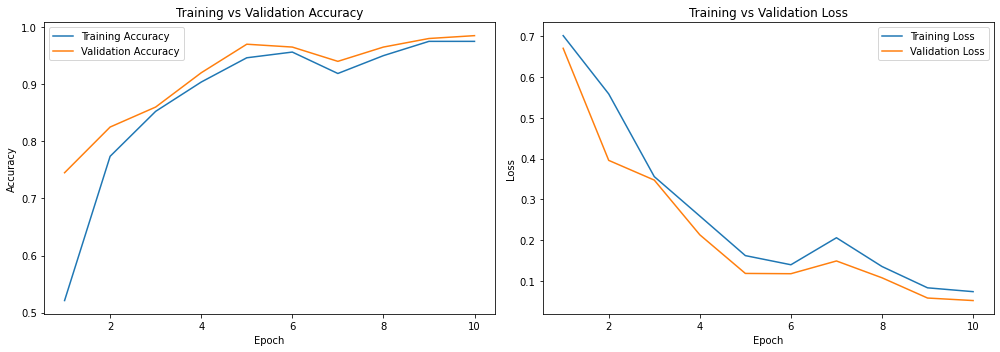

In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Conclusion

We built a CNN using only TensorFlow/Keras that:
- Loads and preprocesses Car vs Motorcycle images (resize to 128x128, normalize to 0-1)
- Splits data into training and testing sets
- Uses Conv2D + ReLU + MaxPooling + Flatten + Dense + Sigmoid layers
- Trains for 10 epochs using the Adam optimizer and binary crossentropy loss
- Reports test accuracy/loss, shows sample predictions, and plots accuracy/loss curves

**Tip:** If your dataset is small, you can improve accuracy by adding data augmentation (`RandomFlip`, `RandomRotation`, `RandomZoom` layers) before the Conv2D layers, or training for more epochs.